# Screen time vs Mental wellness

Source: https://www.kaggle.com/datasets/amar5693/screen-time-sleep-and-stress-analysis-dataset

Round up the usual suspects!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_theme()
import statsmodels.formula.api as smf
from scipy import stats

In [2]:
screen = pd.read_csv('data/ScreenTime vs MentalWellness.csv')

## Exploratory analysis

In [4]:
screen.head()

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3,NaN
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2,NaN
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6,NaN
3,U0004,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0,NaN
4,U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0,NaN


In [5]:
screen.describe()

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
count,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,0.0
mean,29.77750,9.024900,2.183075,6.841825,7.013175,1.397500,8.150500,54.306500,109.810000,7.905000,20.326750,NaN
std,7.46608,2.491058,1.931321,2.220896,0.852421,0.652348,2.094844,15.020054,70.007045,4.909632,20.376793,NaN
min,16.00000,1.000000,0.110000,0.890000,4.640000,1.000000,0.000000,20.600000,0.000000,0.000000,0.000000,NaN
25%,24.00000,7.372500,0.695000,5.460000,6.397500,1.000000,6.900000,43.600000,58.000000,4.575000,3.675000,NaN
50%,30.00000,9.090000,1.455000,6.700000,7.030000,1.000000,8.800000,51.750000,103.000000,7.750000,14.800000,NaN
75%,35.00000,10.495000,3.012500,8.417500,7.640000,2.000000,10.000000,63.000000,157.000000,11.025000,30.650000,NaN
max,60.00000,19.170000,12.040000,13.350000,9.740000,4.000000,10.000000,100.000000,372.000000,23.900000,97.000000,NaN


Most of these values seem fairly close to the mean. The median might be a more reliable indicator of central tendency for age, productivity, exercise hours per week, and mental wellness.

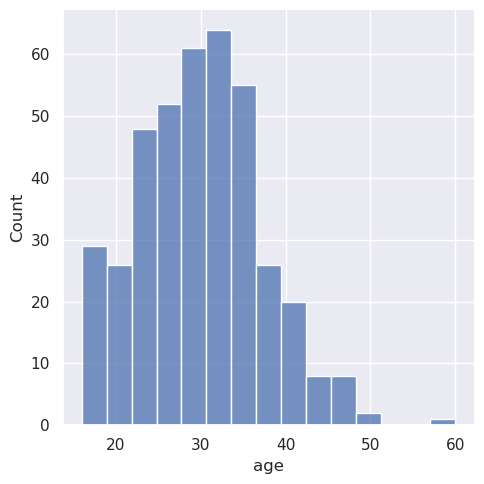

In [9]:
sns.displot(x='age',data=screen)

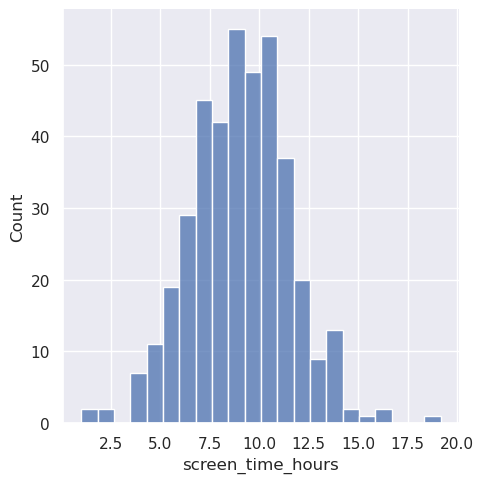

In [10]:
sns.displot(x='screen_time_hours',data=screen)

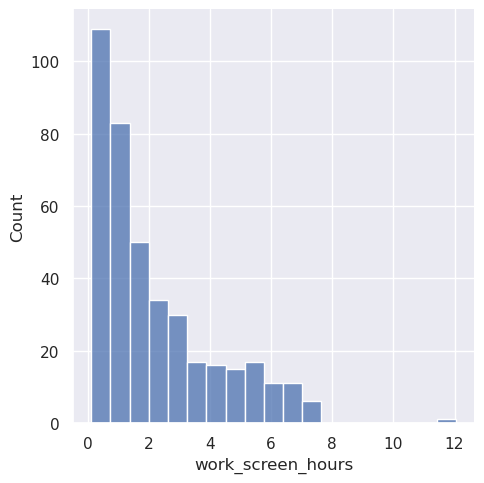

In [11]:
sns.displot(x='work_screen_hours',data=screen)

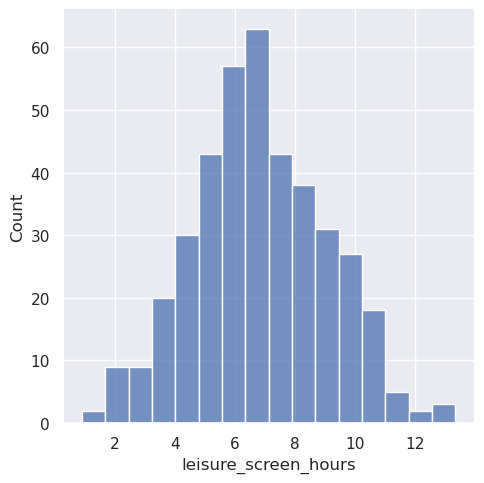

In [12]:
sns.displot(x='leisure_screen_hours',data=screen)

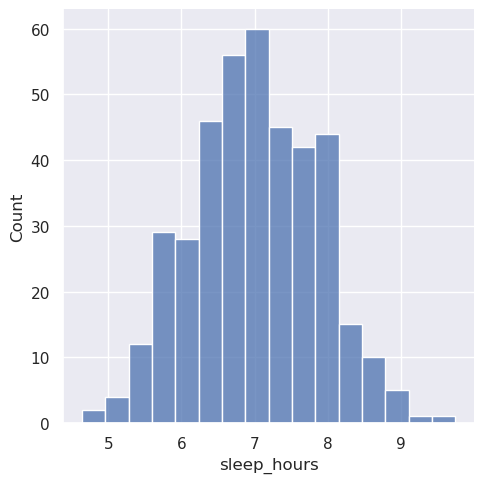

In [13]:
sns.displot(x='sleep_hours',data=screen)

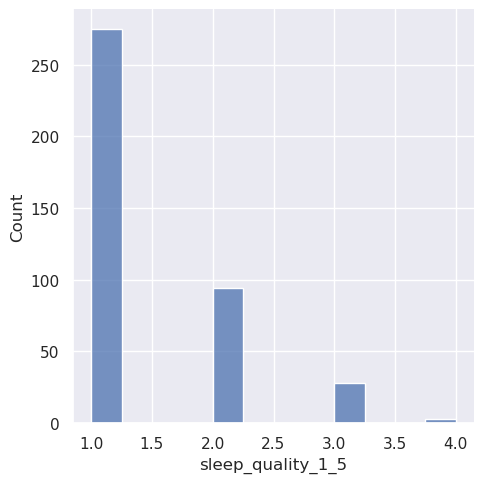

In [14]:
sns.displot(x='sleep_quality_1_5',data=screen)

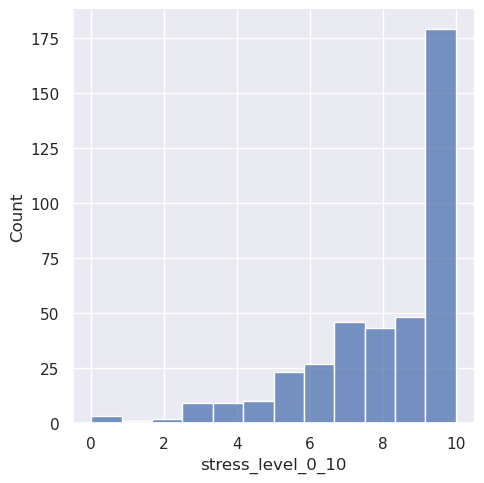

In [16]:
sns.displot(x='stress_level_0_10',data=screen)

Striking how most people rated their stress a 10.

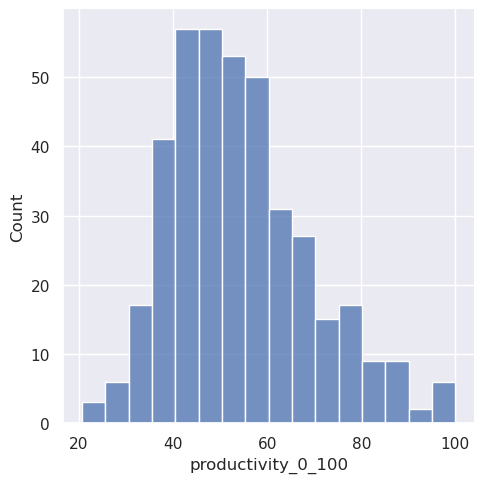

In [17]:
sns.displot(x='productivity_0_100',data=screen)

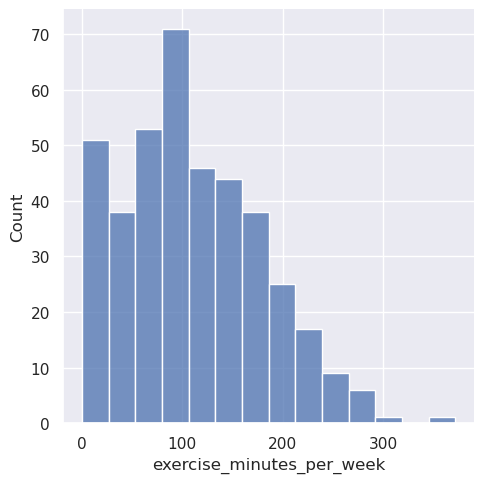

In [18]:
sns.displot(x='exercise_minutes_per_week',data=screen)

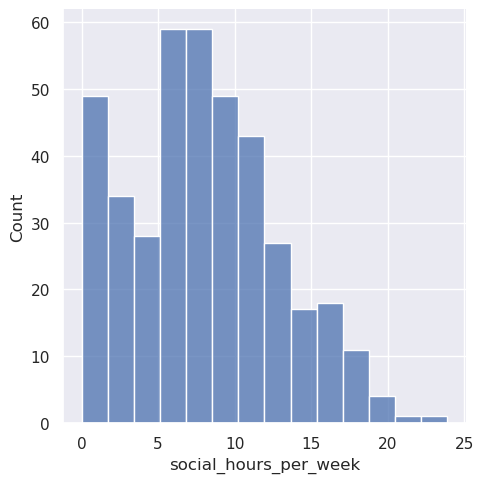

In [19]:
sns.displot(x='social_hours_per_week',data=screen)

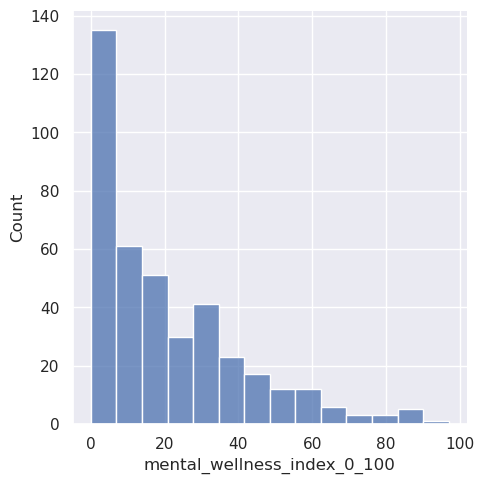

In [22]:
sns.displot(x='mental_wellness_index_0_100',data=screen)

Also striking how low people rate themselves.

## Regression analysis

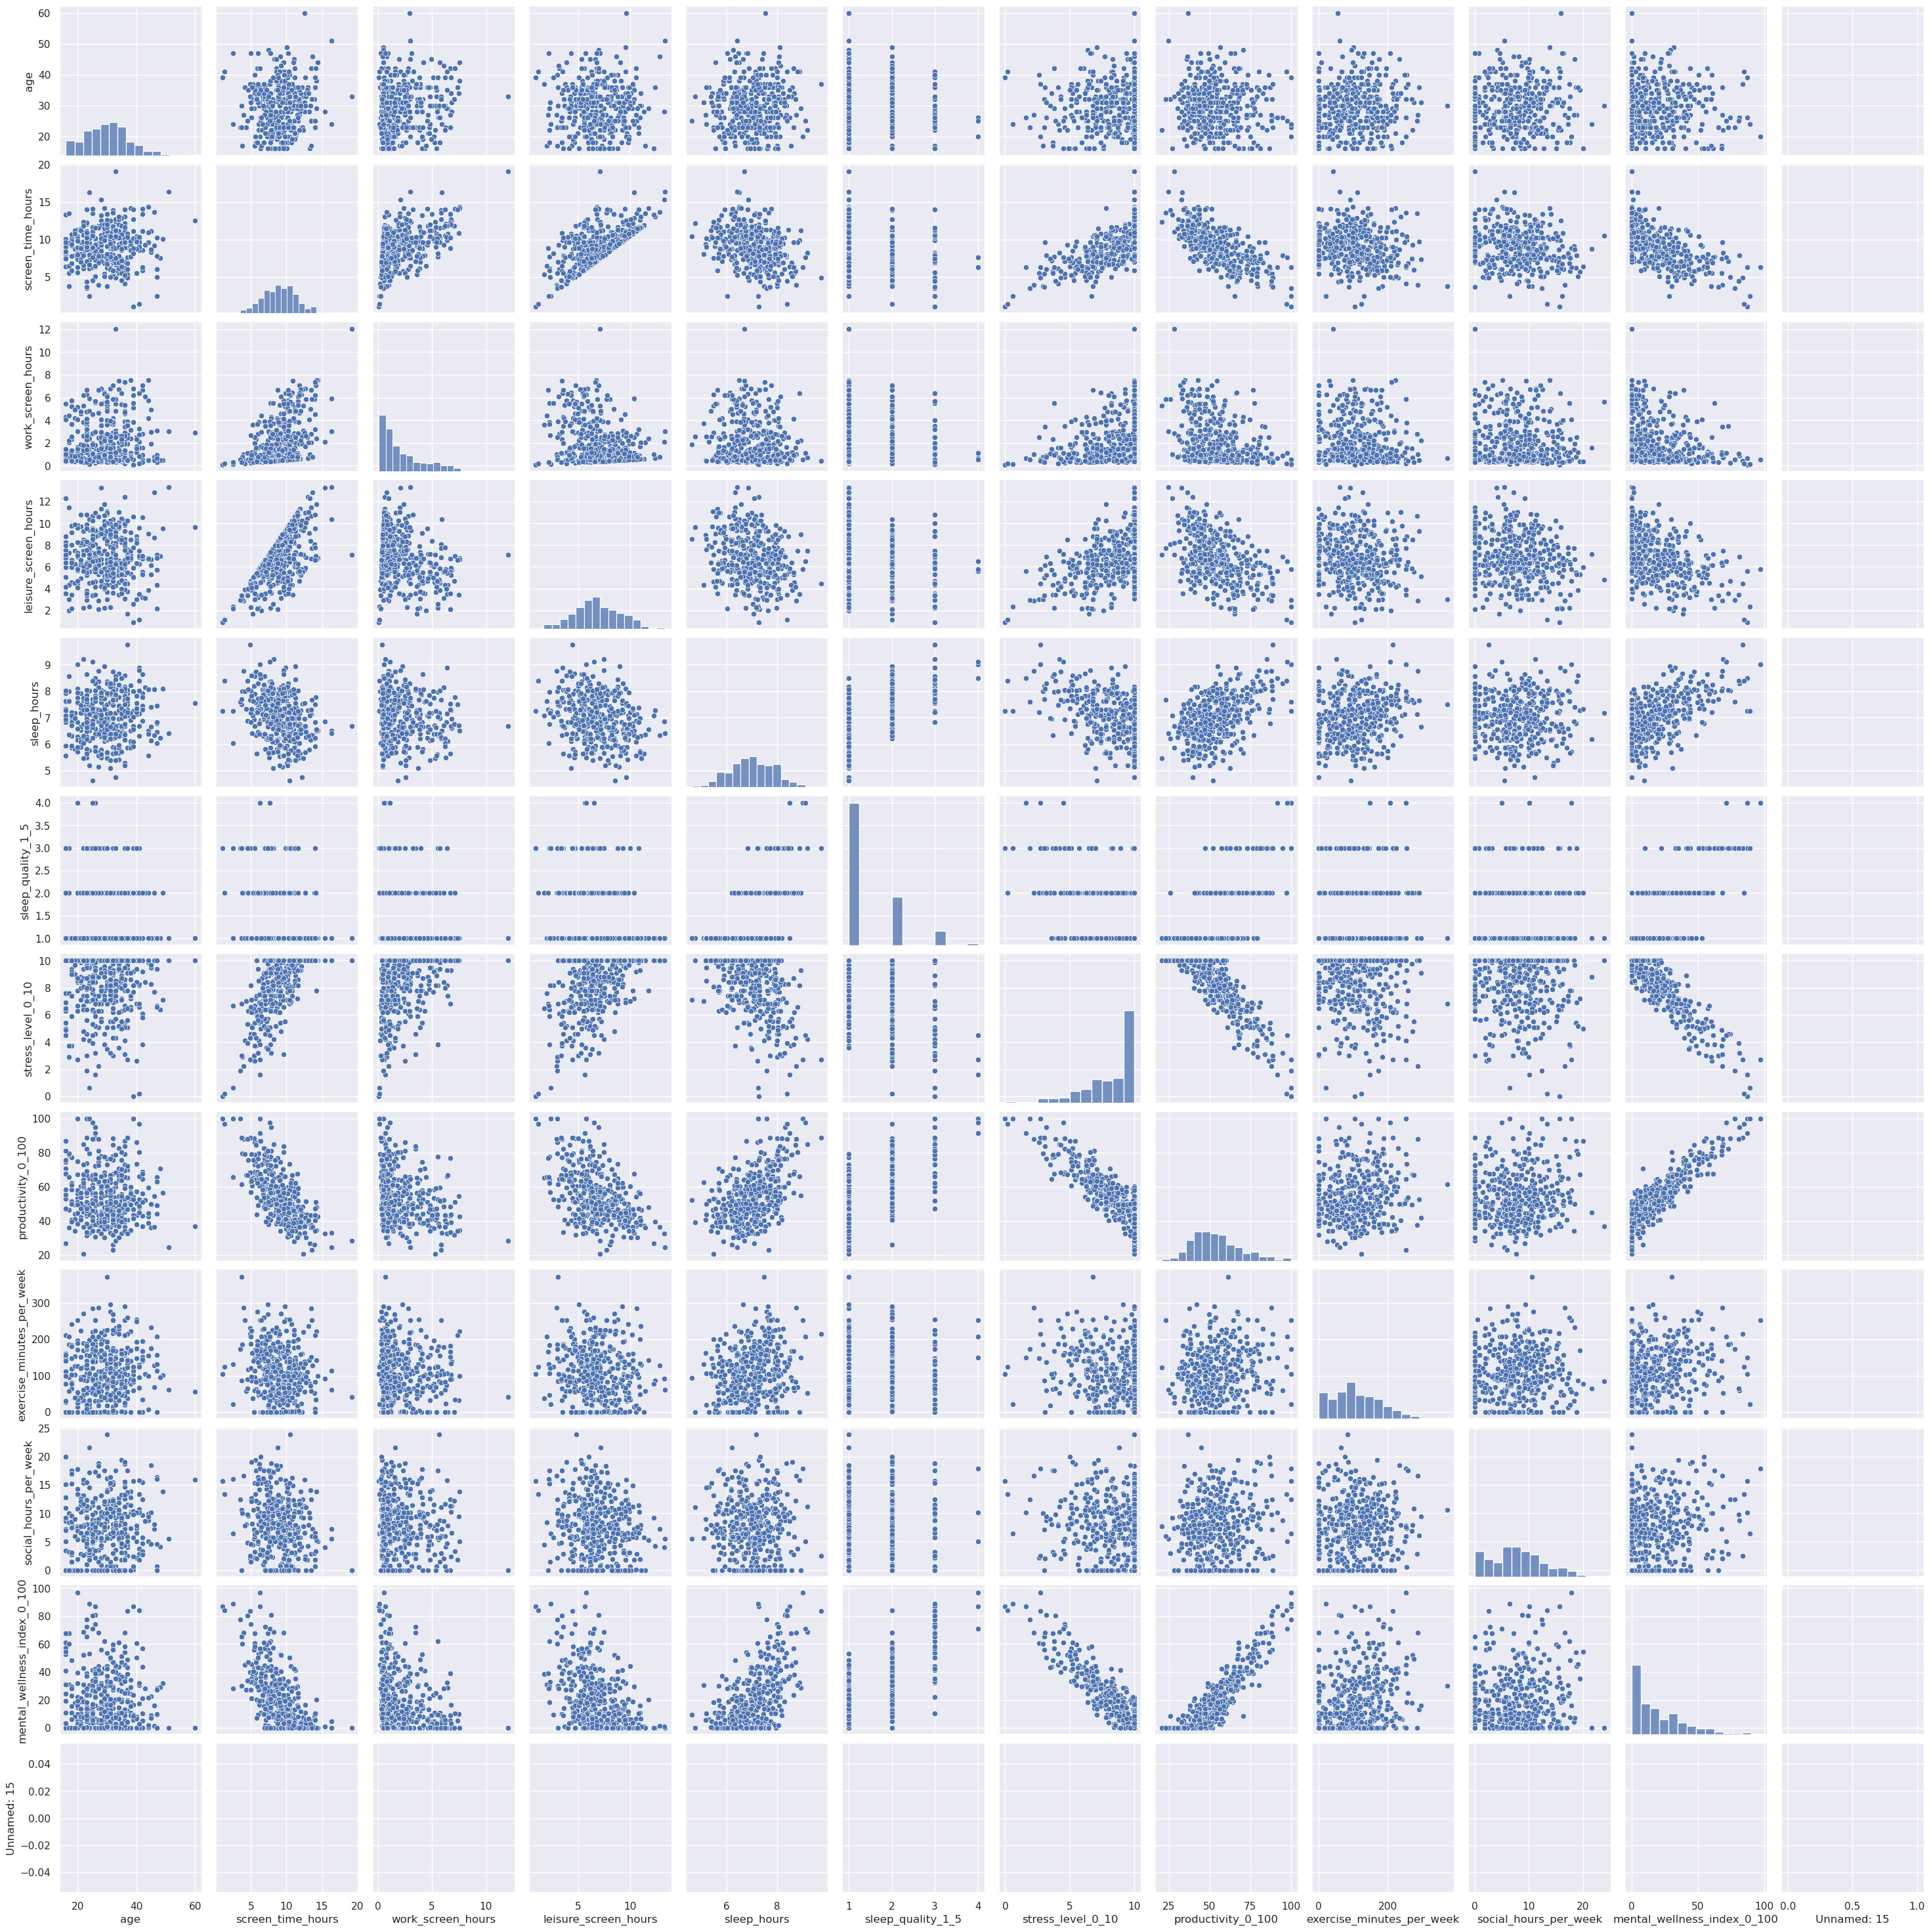

In [23]:
sns.pairplot(screen)

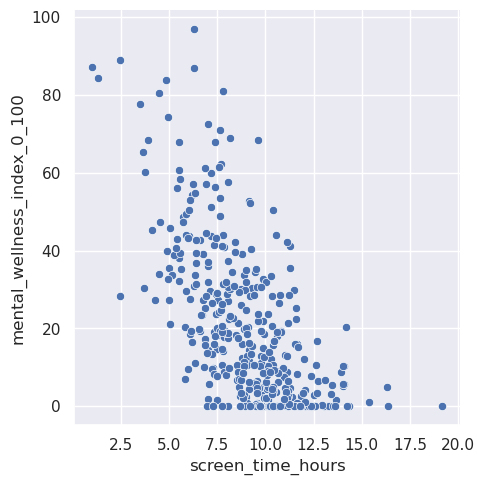

In [25]:
sns.relplot(x='screen_time_hours',y='mental_wellness_index_0_100',data=screen)

<Axes: xlabel='screen_time_hours', ylabel='mental_wellness_index_0_100'>

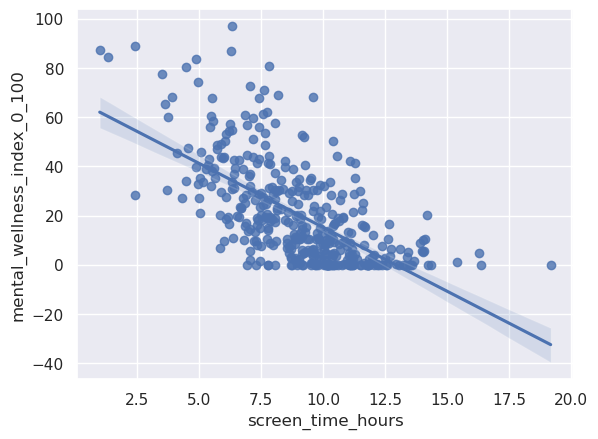

In [26]:
sns.regplot(x='screen_time_hours',y='mental_wellness_index_0_100',data=screen)

In [27]:
results = smf.ols("mental_wellness_index_0_100 ~ screen_time_hours",data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     mental_wellness_index_0_100   R-squared:                       0.404
Model:                                     OLS   Adj. R-squared:                  0.403
Method:                          Least Squares   F-statistic:                     270.3
Date:                         Fri, 20 Feb 2026   Prob (F-statistic):           1.02e-46
Time:                                 19:37:10   Log-Likelihood:                -1669.2
No. Observations:                          400   AIC:                             3342.
Df Residuals:                              398   BIC:                             3350.
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            67.2743      2.962     22.710      0.000      61.451      73.098
screen_time_hours    -5.2020      0.316    -16.440      0.000      -5.824      -4.580
==============================================================================
Omnibus:                       51.291   Durbin-Watson:                   2.061
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               69.274
Skew:                           0.906   Prob(JB):                     9.06e-16
Kurtosis:                       3.934   Cond. No.                         35.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

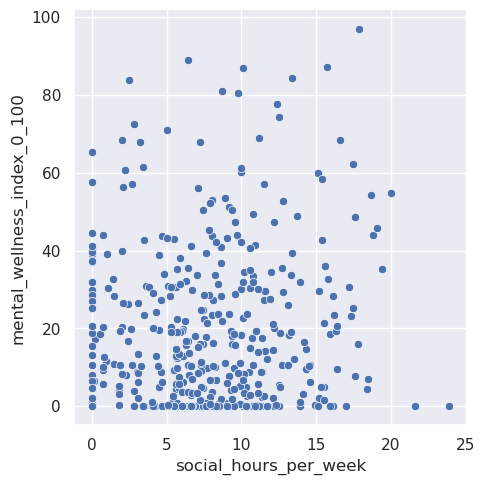

In [28]:
sns.relplot(x='social_hours_per_week',y='mental_wellness_index_0_100',data=screen)

<Axes: xlabel='social_hours_per_week', ylabel='mental_wellness_index_0_100'>

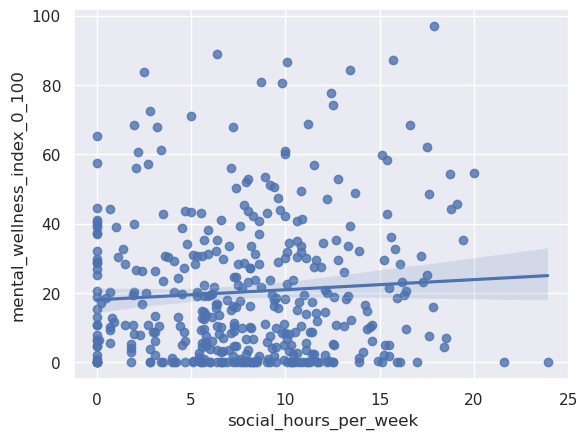

In [29]:
sns.regplot(x='social_hours_per_week',y='mental_wellness_index_0_100',data=screen)

In [31]:
results = smf.ols("mental_wellness_index_0_100 ~ social_hours_per_week",data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     mental_wellness_index_0_100   R-squared:                       0.005
Model:                                     OLS   Adj. R-squared:                  0.002
Method:                          Least Squares   F-statistic:                     1.982
Date:                         Fri, 20 Feb 2026   Prob (F-statistic):              0.160
Time:                                 19:38:42   Log-Likelihood:                -1771.8
No. Observations:                          400   AIC:                             3548.
Df Residuals:                              398   BIC:                             3556.
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                18.0170      1.930      9.333      0.000      14.222      21.812
social_hours_per_week     0.2922      0.208      1.408      0.160      -0.116       0.700
==============================================================================
Omnibus:                       74.917   Durbin-Watson:                   2.169
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              114.399
Skew:                           1.195   Prob(JB):                     1.44e-25
Kurtosis:                       4.072   Cond. No.                         17.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

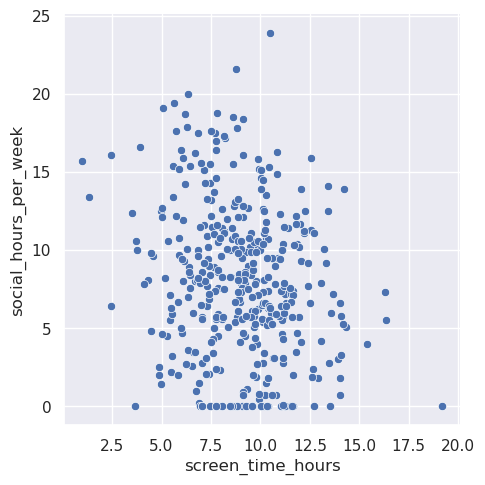

In [33]:
sns.relplot(x='screen_time_hours',y='social_hours_per_week',data=screen)

<Axes: xlabel='screen_time_hours', ylabel='social_hours_per_week'>

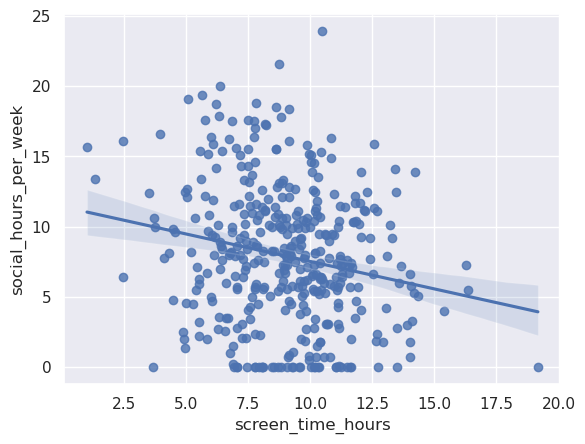

In [34]:
sns.regplot(x='screen_time_hours',y='social_hours_per_week',data=screen)

Interesting. There seems to be a negative correlation between screen time and time spent on social media.

In [35]:
results = smf.ols('social_hours_per_week ~ screen_time_hours',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     social_hours_per_week   R-squared:                       0.039
Model:                               OLS   Adj. R-squared:                  0.037
Method:                    Least Squares   F-statistic:                     16.26
Date:                   Fri, 20 Feb 2026   Prob (F-statistic):           6.62e-05
Time:                           19:41:13   Log-Likelihood:                -1195.5
No. Observations:                    400   AIC:                             2395.
Df Residuals:                        398   BIC:                             2403.
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            11.4291      0.907     12.608      0.000       9.647      13.211
screen_time_hours    -0.3905      0.097     -4.033      0.000      -0.581      -0.200
==============================================================================
Omnibus:                        5.020   Durbin-Watson:                   2.044
Prob(Omnibus):                  0.081   Jarque-Bera (JB):                4.694
Skew:                           0.211   Prob(JB):                       0.0957
Kurtosis:                       2.679   Cond. No.                         35.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [36]:
from scipy import stats
stats.pearsonr(screen['screen_time_hours'],screen['social_hours_per_week'])

PearsonRResult(statistic=np.float64(-0.19812441441049422), pvalue=np.float64(6.615520159272382e-05))

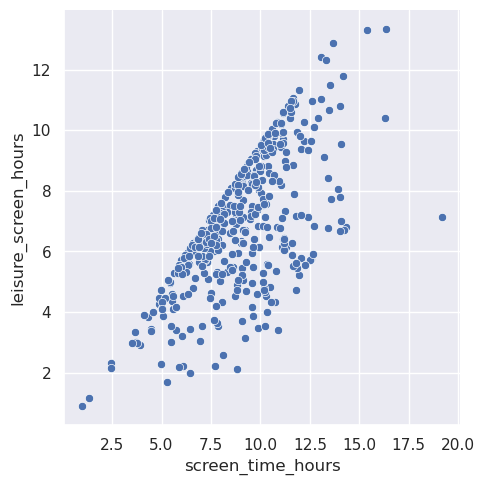

In [37]:
sns.relplot(x='screen_time_hours',y='leisure_screen_hours',data=screen)

<Axes: xlabel='screen_time_hours', ylabel='leisure_screen_hours'>

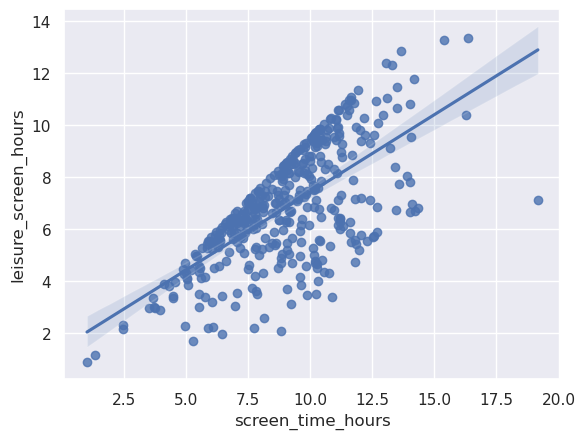

In [38]:
sns.regplot(x='screen_time_hours',y='leisure_screen_hours',data=screen)

In [39]:
results = smf.ols('leisure_screen_hours ~ screen_time_hours',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     leisure_screen_hours   R-squared:                       0.448
Model:                              OLS   Adj. R-squared:                  0.447
Method:                   Least Squares   F-statistic:                     323.3
Date:                  Fri, 20 Feb 2026   Prob (F-statistic):           2.44e-53
Time:                          19:44:48   Log-Likelihood:                -767.32
No. Observations:                   400   AIC:                             1539.
Df Residuals:                       398   BIC:                             1547.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             1.4550      0.311      4.682      0.000       0.844       2.066
screen_time_hours     0.5969      0.033     17.980      0.000       0.532       0.662
==============================================================================
Omnibus:                       26.475   Durbin-Watson:                   2.048
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               30.604
Skew:                          -0.676   Prob(JB):                     2.26e-07
Kurtosis:                       2.902   Cond. No.                         35.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

I guess leisure screen hours being correlated with leisure screen hours isn't really a surprise.

I want to switch the variables around.

In [40]:
results = smf.ols('screen_time_hours ~ leisure_screen_hours ',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      screen_time_hours   R-squared:                       0.448
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     323.3
Date:                Fri, 20 Feb 2026   Prob (F-statistic):           2.44e-53
Time:                        19:46:05   Log-Likelihood:                -813.24
No. Observations:                 400   AIC:                             1630.
Df Residuals:                     398   BIC:                             1638.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                3.8872      0.300     12.941      0.000       3.297       4.478
leisure_screen_hours     0.7509      0.042     17.980      0.000       0.669       0.833
==============================================================================
Omnibus:                       80.986   Durbin-Watson:                   2.110
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              143.121
Skew:                           1.153   Prob(JB):                     8.35e-32
Kurtosis:                       4.808   Cond. No.                         23.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The standard error seems slightly higher the other way around.

Now I want to try some multiple regression.

In [42]:
results = smf.ols('mental_wellness_index_0_100 ~ screen_time_hours + social_hours_per_week + leisure_screen_hours + work_screen_hours',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     mental_wellness_index_0_100   R-squared:                       0.411
Model:                                     OLS   Adj. R-squared:                  0.406
Method:                          Least Squares   F-statistic:                     92.00
Date:                         Fri, 20 Feb 2026   Prob (F-statistic):           3.41e-45
Time:                                 19:53:49   Log-Likelihood:                -1667.1
No. Observations:                          400   AIC:                             3342.
Df Residuals:                              396   BIC:                             3358.
Df Model:                                    3                                         
Covariance Type:                     nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                71.1838      3.587     19.846      0.000      64.132      78.235
screen_time_hours        -3.4899      0.216    -16.122      0.000      -3.915      -3.064
social_hours_per_week    -0.2546      0.164     -1.556      0.121      -0.576       0.067
leisure_screen_hours     -2.0886      0.249     -8.392      0.000      -2.578      -1.599
work_screen_hours        -1.4013      0.275     -5.102      0.000      -1.941      -0.861
==============================================================================
Omnibus:                       54.456   Durbin-Watson:                   2.070
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               76.005
Skew:                           0.928   Prob(JB):                     3.13e-17
Kurtosis:                       4.055   Cond. No.                     2.47e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.36e-28. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [43]:
results = smf.ols('screen_time_hours ~ social_hours_per_week + leisure_screen_hours + work_screen_hours',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      screen_time_hours   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.779e+32
Date:                Fri, 20 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:55:05   Log-Likelihood:                 12943.
No. Observations:                 400   AIC:                        -2.588e+04
Df Residuals:                     396   BIC:                        -2.586e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              3.331e-16   4.92e-16      0.677      0.499   -6.34e-16     1.3e-15
social_hours_per_week  9.368e-17   2.24e-17      4.173      0.000    4.95e-17    1.38e-16
leisure_screen_hours      1.0000   5.17e-17   1.93e+16      0.000       1.000       1.000
work_screen_hours         1.0000   5.86e-17   1.71e+16      0.000       1.000       1.000
==============================================================================
Omnibus:                       30.562   Durbin-Watson:                   0.767
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               36.867
Skew:                          -0.642   Prob(JB):                     9.87e-09
Kurtosis:                       3.749   Cond. No.                         52.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

I think this is overfit. This is the first time I've seen an $R^2$ of 1 with real data.

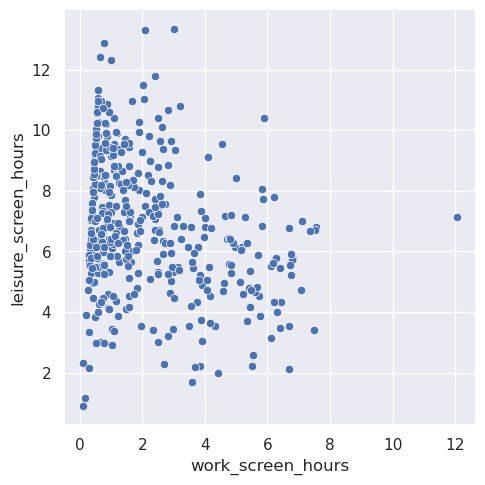

In [44]:
sns.relplot(x='work_screen_hours',y='leisure_screen_hours',data=screen)

<Axes: xlabel='work_screen_hours', ylabel='leisure_screen_hours'>

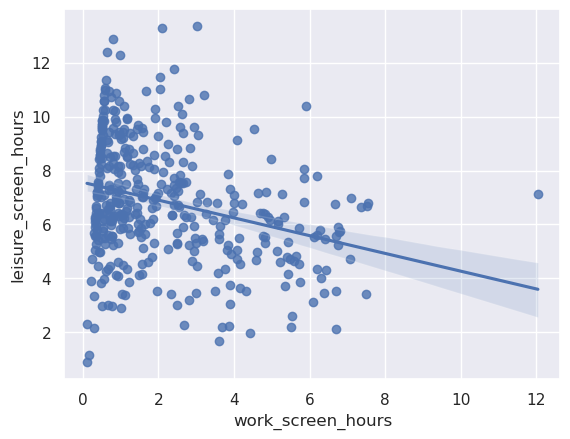

In [45]:
sns.regplot(x='work_screen_hours',y='leisure_screen_hours',data=screen)

In [47]:
results = smf.ols('leisure_screen_hours ~ work_screen_hours',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     leisure_screen_hours   R-squared:                       0.082
Model:                              OLS   Adj. R-squared:                  0.080
Method:                   Least Squares   F-statistic:                     35.57
Date:                  Fri, 20 Feb 2026   Prob (F-statistic):           5.44e-09
Time:                          20:06:09   Log-Likelihood:                -869.12
No. Observations:                   400   AIC:                             1742.
Df Residuals:                       398   BIC:                             1750.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             7.5608      0.161     46.996      0.000       7.245       7.877
work_screen_hours    -0.3294      0.055     -5.964      0.000      -0.438      -0.221
==============================================================================
Omnibus:                        0.906   Durbin-Watson:                   2.090
Prob(Omnibus):                  0.636   Jarque-Bera (JB):                0.683
Skew:                           0.045   Prob(JB):                        0.711
Kurtosis:                       3.182   Cond. No.                         4.71
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [49]:
stats.pearsonr(screen['work_screen_hours'],screen['leisure_screen_hours'])

PearsonRResult(statistic=np.float64(-0.2864136208530663), pvalue=np.float64(5.444263794795794e-09))

Indeed, there seems to be a negative correlation between screen hours at work and for leisure. Maybe people who work with screens all day want to get away for a while?

Let's look at stress levels.

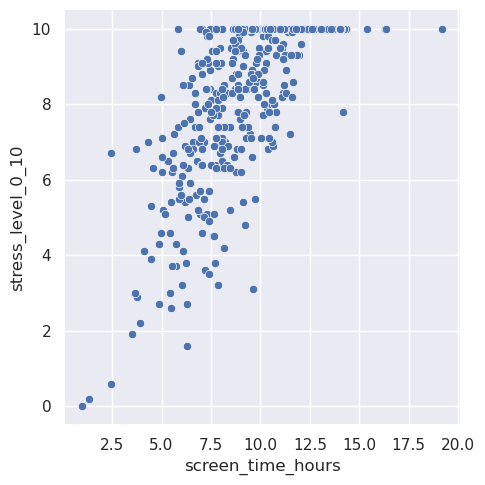

In [3]:
sns.relplot(x="screen_time_hours",y="stress_level_0_10",data=screen)

<Axes: xlabel='screen_time_hours', ylabel='stress_level_0_10'>

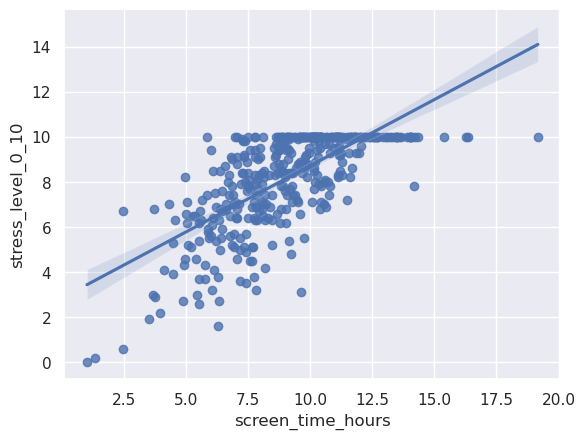

In [4]:
sns.regplot(x="screen_time_hours",y="stress_level_0_10",data=screen)

In [5]:
stats.pearsonr(screen["screen_time_hours"],screen["stress_level_0_10"])

PearsonRResult(statistic=np.float64(0.6978118392584454), pvalue=np.float64(1.2024981763312574e-59))

In [6]:
results = smf.ols('stress_level_0_10 ~ screen_time_hours',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      stress_level_0_10   R-squared:                       0.487
Model:                            OLS   Adj. R-squared:                  0.486
Method:                 Least Squares   F-statistic:                     377.7
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           1.20e-59
Time:                        15:28:59   Log-Likelihood:                -729.39
No. Observations:                 400   AIC:                             1463.
Df Residuals:                     398   BIC:                             1471.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             2.8545      0.283     10.099      0.000       2.299       3.410
screen_time_hours     0.5868      0.030     19.436      0.000       0.527       0.646
==============================================================================
Omnibus:                       26.028   Durbin-Watson:                   2.073
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               29.230
Skew:                          -0.634   Prob(JB):                     4.50e-07
Kurtosis:                       3.382   Cond. No.                         35.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Seems to be a pretty good correlation between screen time and stress. But it's not necessarily true that screen time causes stress. I want to compare stress vs leisure screen time.

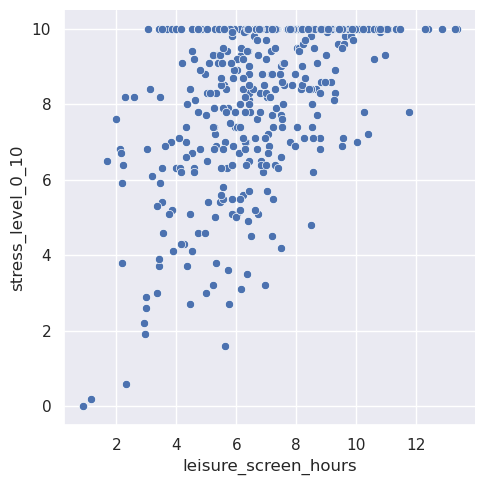

In [7]:
sns.relplot(x='leisure_screen_hours',y='stress_level_0_10',data=screen)

<Axes: xlabel='leisure_screen_hours', ylabel='stress_level_0_10'>

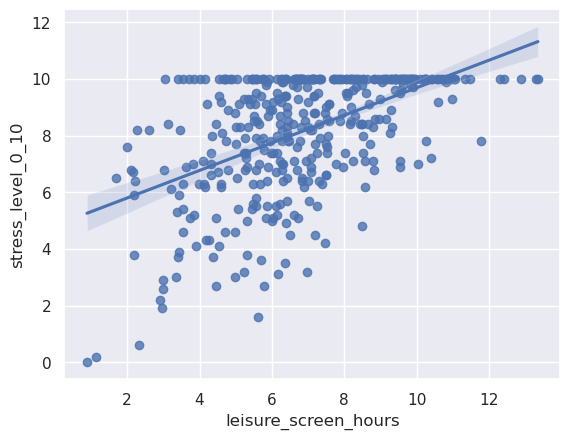

In [8]:
sns.regplot(x='leisure_screen_hours',y='stress_level_0_10',data=screen)

In [12]:
stats.pearsonr(screen['leisure_screen_hours'],screen['stress_level_0_10'])

PearsonRResult(statistic=np.float64(0.5153580006047954), pvalue=np.float64(1.6143098321663583e-28))

In [11]:
results = smf.ols('stress_level_0_10 ~ leisure_screen_hours',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      stress_level_0_10   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     143.9
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           1.61e-28
Time:                        15:36:37   Log-Likelihood:                -801.13
No. Observations:                 400   AIC:                             1606.
Df Residuals:                     398   BIC:                             1614.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                4.8246      0.291     16.555      0.000       4.252       5.398
leisure_screen_hours     0.4861      0.041     11.997      0.000       0.406       0.566
==============================================================================
Omnibus:                       29.817   Durbin-Watson:                   2.168
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               34.335
Skew:                          -0.698   Prob(JB):                     3.50e-08
Kurtosis:                       3.330   Cond. No.                         23.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

There's a correlation between leisure screen time too.

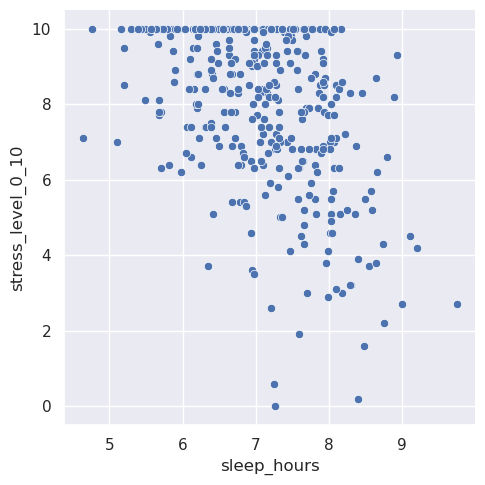

In [13]:
sns.relplot(x='sleep_hours',y='stress_level_0_10',data=screen)

<Axes: xlabel='sleep_hours', ylabel='stress_level_0_10'>

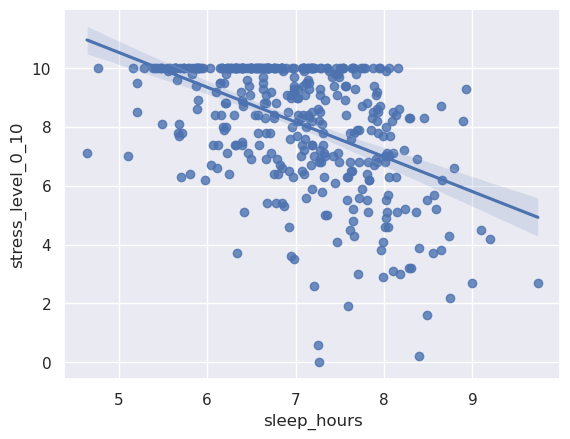

In [14]:
sns.regplot(x='sleep_hours',y='stress_level_0_10',data=screen)

In [16]:
stats.pearsonr(screen['sleep_hours'],screen['stress_level_0_10'])

PearsonRResult(statistic=np.float64(-0.48113697323005344), pvalue=np.float64(1.4449929573029924e-24))

There seems to be a negative correlation between sleep and stress.

In [19]:
results = smf.ols('stress_level_0_10 ~ sleep_hours',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      stress_level_0_10   R-squared:                       0.231
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     119.9
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           1.44e-24
Time:                        15:54:21   Log-Likelihood:                -810.21
No. Observations:                 400   AIC:                             1624.
Df Residuals:                     398   BIC:                             1632.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      16.4429      0.763     21.553      0.000      14.943      17.943
sleep_hours    -1.1824      0.108    -10.949      0.000      -1.395      -0.970
==============================================================================
Omnibus:                       59.830   Durbin-Watson:                   2.234
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               87.371
Skew:                          -0.976   Prob(JB):                     1.07e-19
Kurtosis:                       4.195   Cond. No.                         59.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

I want to look at how other things in conjuction with screen time, such as sleep and exercise, affect stress.

In [21]:
results = smf.ols('stress_level_0_10 ~ screen_time_hours + sleep_hours + sleep_quality_1_5 + productivity_0_100 + exercise_minutes_per_week',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      stress_level_0_10   R-squared:                       0.787
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     291.9
Date:                Sun, 22 Feb 2026   Prob (F-statistic):          4.77e-130
Time:                        15:57:06   Log-Likelihood:                -553.15
No. Observations:                 400   AIC:                             1118.
Df Residuals:                     394   BIC:                             1142.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    13.2645      0.668     19.847      0.000      11.951      14.578
screen_time_hours             0.1317      0.030      4.458      0.000       0.074       0.190
sleep_hours                  -0.0778      0.075     -1.038      0.300      -0.225       0.070
sleep_quality_1_5            -0.0567      0.115     -0.494      0.622      -0.282       0.169
productivity_0_100           -0.1029      0.006    -16.841      0.000      -0.115      -0.091
exercise_minutes_per_week    -0.0008      0.001     -1.169      0.243      -0.002       0.001
==============================================================================
Omnibus:                        7.991   Durbin-Watson:                   1.982
Prob(Omnibus):                  0.018   Jarque-Bera (JB):                8.058
Skew:                          -0.347   Prob(JB):                       0.0178
Kurtosis:                       3.032   Cond. No.                     1.93e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.93e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Productivity seems to be the most negatively correlated with stress compared to exercise. And sleep quality doesn't seem that explanatory at all. Even exercise doesn't seem to be correlated with stress. I think I might want to adjust my model, since it seems to be collinnear.

In [35]:
results = smf.ols('stress_level_0_10 ~ screen_time_hours + sleep_hours + productivity_0_100 + exercise_minutes_per_week',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      stress_level_0_10   R-squared:                       0.787
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     365.6
Date:                Sun, 22 Feb 2026   Prob (F-statistic):          2.65e-131
Time:                        16:44:16   Log-Likelihood:                -553.28
No. Observations:                 400   AIC:                             1117.
Df Residuals:                     395   BIC:                             1137.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    13.4327      0.574     23.383      0.000      12.303      14.562
screen_time_hours             0.1268      0.028      4.557      0.000       0.072       0.182
sleep_hours                  -0.0938      0.067     -1.390      0.165      -0.227       0.039
productivity_0_100           -0.1045      0.005    -20.676      0.000      -0.114      -0.095
exercise_minutes_per_week    -0.0008      0.001     -1.164      0.245      -0.002       0.001
==============================================================================
Omnibus:                        8.008   Durbin-Watson:                   1.976
Prob(Omnibus):                  0.018   Jarque-Bera (JB):                8.068
Skew:                          -0.347   Prob(JB):                       0.0177
Kurtosis:                       3.038   Cond. No.                     1.65e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.65e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [23]:
results = smf.ols('stress_level_0_10 ~ screen_time_hours + sleep_hours',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      stress_level_0_10   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     249.7
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           6.15e-71
Time:                        20:52:17   Log-Likelihood:                -699.98
No. Observations:                 400   AIC:                             1406.
Df Residuals:                     397   BIC:                             1418.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             8.3994      0.747     11.245      0.000       6.931       9.868
screen_time_hours     0.5086      0.030     17.085      0.000       0.450       0.567
sleep_hours          -0.6900      0.087     -7.931      0.000      -0.861      -0.519
==============================================================================
Omnibus:                       19.175   Durbin-Watson:                   2.094
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               20.580
Skew:                          -0.541   Prob(JB):                     3.40e-05
Kurtosis:                       3.257   Cond. No.                         125.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [24]:
results = smf.ols('stress_level_0_10 ~ screen_time_hours + sleep_hours + sleep_quality_1_5',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      stress_level_0_10   R-squared:                       0.634
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                     228.9
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           4.11e-86
Time:                        20:52:50   Log-Likelihood:                -661.71
No. Observations:                 400   AIC:                             1331.
Df Residuals:                     396   BIC:                             1347.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             6.6363      0.706      9.393      0.000       5.247       8.025
screen_time_hours     0.4836      0.027     17.763      0.000       0.430       0.537
sleep_hours          -0.1800      0.097     -1.859      0.064      -0.370       0.010
sleep_quality_1_5    -1.1361      0.124     -9.139      0.000      -1.381      -0.892
==============================================================================
Omnibus:                       13.702   Durbin-Watson:                   2.182
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               14.169
Skew:                          -0.431   Prob(JB):                     0.000838
Kurtosis:                       3.329   Cond. No.                         131.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

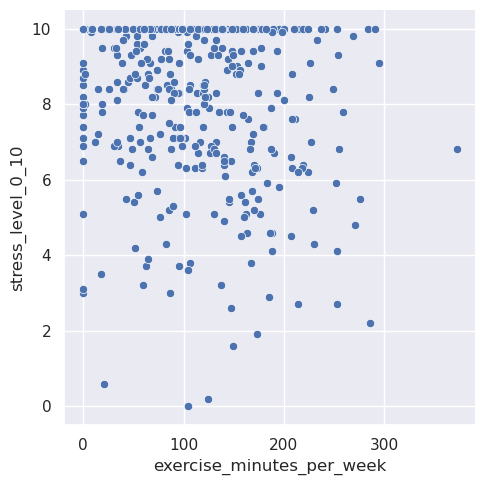

In [27]:
sns.relplot(x='exercise_minutes_per_week',y='stress_level_0_10',data=screen)

<Axes: xlabel='exercise_minutes_per_week', ylabel='stress_level_0_10'>

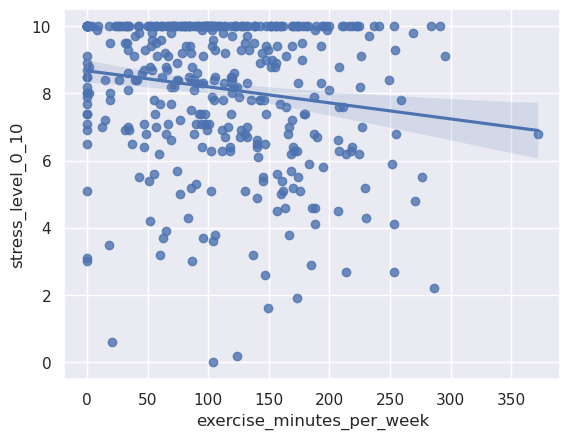

In [28]:
sns.regplot(x='exercise_minutes_per_week',y='stress_level_0_10',data=screen)

In [26]:
results = smf.ols('stress_level_0_10 ~ exercise_minutes_per_week',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      stress_level_0_10   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     10.41
Date:                Sun, 22 Feb 2026   Prob (F-statistic):            0.00136
Time:                        20:53:52   Log-Likelihood:                -857.70
No. Observations:                 400   AIC:                             1719.
Df Residuals:                     398   BIC:                             1727.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     8.6752      0.193     45.006      0.000       8.296       9.054
exercise_minutes_per_week    -0.0048      0.001     -3.227      0.001      -0.008      -0.002
==============================================================================
Omnibus:                       77.157   Durbin-Watson:                   2.183
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              121.409
Skew:                          -1.193   Prob(JB):                     4.33e-27
Kurtosis:                       4.261   Cond. No.                         242.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Not much correlation between exercise and stress.

In [38]:
np.sqrt(results.rsquared_adj)

np.float64(0.8860932346222966)

Pretty strong fit.

I think it might be interesting to look at associations between productivity and stress.

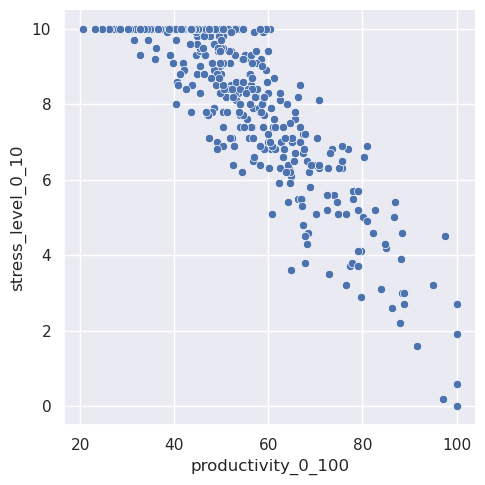

In [23]:
sns.relplot(x='productivity_0_100',y='stress_level_0_10',data=screen)

<Axes: xlabel='productivity_0_100', ylabel='stress_level_0_10'>

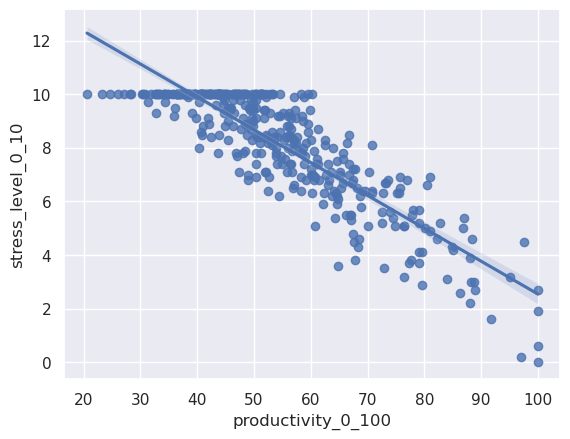

In [24]:
sns.regplot(x='productivity_0_100',y='stress_level_0_10',data=screen)

In [25]:
stats.pearsonr(screen['productivity_0_100'],screen['stress_level_0_10'])

PearsonRResult(statistic=np.float64(-0.8795386072174745), pvalue=np.float64(1.9146117257788864e-130))

In [26]:
results = smf.ols('stress_level_0_10 ~ productivity_0_100',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      stress_level_0_10   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     1360.
Date:                Sun, 22 Feb 2026   Prob (F-statistic):          1.91e-130
Time:                        16:35:51   Log-Likelihood:                -565.79
No. Observations:                 400   AIC:                             1136.
Df Residuals:                     398   BIC:                             1144.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             14.8122      0.187     79.034      0.000      14.444      15.181
productivity_0_100    -0.1227      0.003    -36.876      0.000      -0.129      -0.116
==============================================================================
Omnibus:                        5.517   Durbin-Watson:                   1.984
Prob(Omnibus):                  0.063   Jarque-Bera (JB):                5.485
Skew:                          -0.287   Prob(JB):                       0.0644
Kurtosis:                       3.007   Cond. No.                         212.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Pretty strong negative correlation on its own between productivity and stress, what about the other way around?

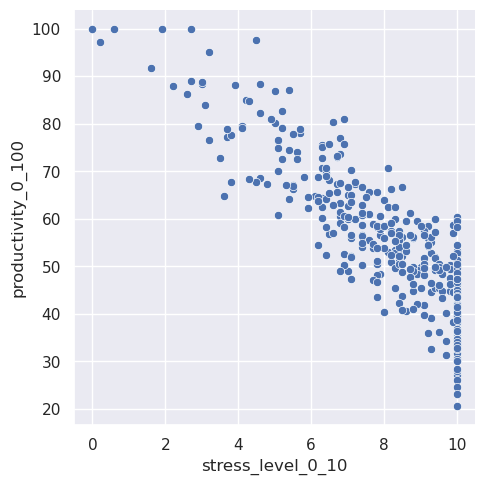

In [30]:
sns.relplot(x='stress_level_0_10',y='productivity_0_100',data=screen)

<Axes: xlabel='stress_level_0_10', ylabel='productivity_0_100'>

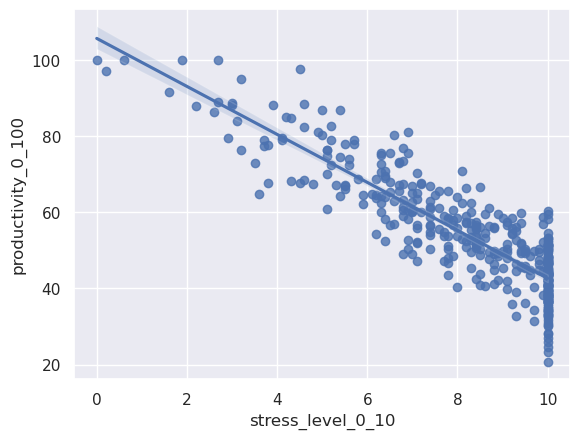

In [29]:
sns.regplot(x='stress_level_0_10',y='productivity_0_100',data=screen)

In [31]:
stats.pearsonr(screen['stress_level_0_10'],screen['productivity_0_100'])

PearsonRResult(statistic=np.float64(-0.8795386072174745), pvalue=np.float64(1.9146117257788864e-130))

In [33]:
results = smf.ols('productivity_0_100 ~ stress_level_0_10',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     productivity_0_100   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     1360.
Date:                Sun, 22 Feb 2026   Prob (F-statistic):          1.91e-130
Time:                        16:41:30   Log-Likelihood:                -1353.7
No. Observations:                 400   AIC:                             2711.
Df Residuals:                     398   BIC:                             2719.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           105.7060      1.439     73.457      0.000     102.877     108.535
stress_level_0_10    -6.3063      0.171    -36.876      0.000      -6.643      -5.970
==============================================================================
Omnibus:                        0.198   Durbin-Watson:                   1.920
Prob(Omnibus):                  0.906   Jarque-Bera (JB):                0.212
Skew:                          -0.053   Prob(JB):                        0.900
Kurtosis:                       2.964   Cond. No.                         34.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

np.float64(0.8795386072174742)

Another good fit. The inverse relationship between stress and productivity seems well established. Could concentrating on the task at hand reduce stress?

I think I want to try to build a model for productivity now.

In [41]:
results = smf.ols('productivity_0_100 ~ stress_level_0_10 + screen_time_hours + sleep_hours + + sleep_quality_1_5 + exercise_minutes_per_week',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     productivity_0_100   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     403.0
Date:                Sun, 22 Feb 2026   Prob (F-statistic):          2.02e-152
Time:                        16:54:51   Log-Likelihood:                -1288.7
No. Observations:                 400   AIC:                             2589.
Df Residuals:                     394   BIC:                             2613.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    91.3314      3.764     24.265      0.000      83.932      98.731
stress_level_0_10            -4.0693      0.242    -16.841      0.000      -4.544      -3.594
screen_time_hours            -1.4452      0.176     -8.215      0.000      -1.791      -1.099
sleep_hours                   0.2268      0.472      0.481      0.631      -0.701       1.155
sleep_quality_1_5             5.8837      0.658      8.938      0.000       4.590       7.178
exercise_minutes_per_week    -0.0057      0.004     -1.276      0.203      -0.015       0.003
==============================================================================
Omnibus:                        1.160   Durbin-Watson:                   1.899
Prob(Omnibus):                  0.560   Jarque-Bera (JB):                0.973
Skew:                           0.110   Prob(JB):                        0.615
Kurtosis:                       3.099   Cond. No.                     1.62e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.62e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Interesting, the number of sleep hours is not significant but sleep quality is. I want to look at sleep quality vs sleep hours.

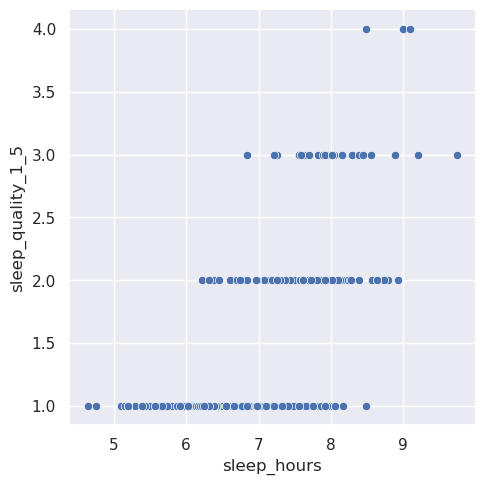

In [42]:
sns.relplot(x='sleep_hours',y='sleep_quality_1_5',data=screen)

<Axes: xlabel='sleep_hours', ylabel='sleep_quality_1_5'>

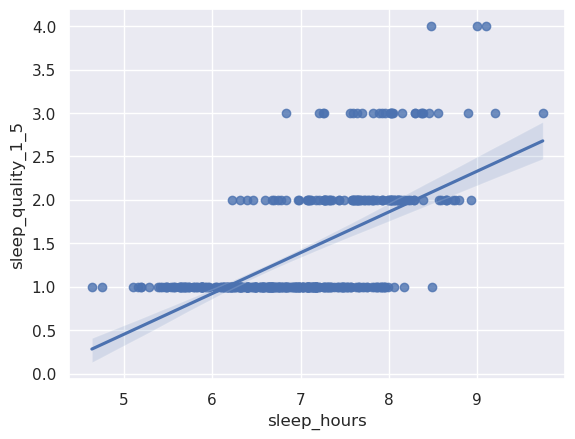

In [43]:
sns.regplot(x='sleep_hours',y='sleep_quality_1_5',data=screen)

In [45]:
stats.pearsonr(screen['sleep_hours'],screen['sleep_quality_1_5'])

PearsonRResult(statistic=np.float64(0.6143814190413448), pvalue=np.float64(7.082252079366493e-43))

In [44]:
results = smf.ols('sleep_quality_1_5 ~ sleep_hours',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      sleep_quality_1_5   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.376
Method:                 Least Squares   F-statistic:                     241.3
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           7.08e-43
Time:                        17:00:03   Log-Likelihood:                -301.41
No. Observations:                 400   AIC:                             606.8
Df Residuals:                     398   BIC:                             614.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.8999      0.214     -8.886      0.000      -2.320      -1.480
sleep_hours     0.4702      0.030     15.535      0.000       0.411       0.530
==============================================================================
Omnibus:                       50.143   Durbin-Watson:                   1.894
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               67.803
Skew:                           0.885   Prob(JB):                     1.89e-15
Kurtosis:                       3.968   Cond. No.                         59.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Seems to be a decent fit, but since sleep quality is ranked I want to see what a nonparmetric correlation reveals.

In [47]:
stats.spearmanr(screen['sleep_hours'],screen['sleep_quality_1_5'])

SignificanceResult(statistic=np.float64(0.6261486478882695), pvalue=np.float64(6.185304101747156e-45))

Slightly higher nonparametric correlation.

In [9]:
results = smf.ols('mental_wellness_index_0_100 ~ screen_time_hours + sleep_hours + productivity_0_100 + exercise_minutes_per_week + sleep_quality_1_5',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     mental_wellness_index_0_100   R-squared:                       0.878
Model:                                     OLS   Adj. R-squared:                  0.877
Method:                          Least Squares   F-statistic:                     569.0
Date:                         Sun, 22 Feb 2026   Prob (F-statistic):          9.91e-178
Time:                                 20:29:25   Log-Likelihood:                -1351.5
No. Observations:                          400   AIC:                             2715.
Df Residuals:                              394   BIC:                             2739.
Df Model:                                    5                                         
Covariance Type:                     nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                   -39.6395      4.918     -8.060      0.000     -49.308     -29.971
screen_time_hours            -0.7333      0.217     -3.374      0.001      -1.161      -0.306
sleep_hours                   0.6937      0.552      1.258      0.209      -0.391       1.778
productivity_0_100            0.8382      0.045     18.650      0.000       0.750       0.927
exercise_minutes_per_week     0.0284      0.005      5.414      0.000       0.018       0.039
sleep_quality_1_5             9.3589      0.844     11.085      0.000       7.699      11.019
==============================================================================
Omnibus:                        0.346   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.841   Jarque-Bera (JB):                0.414
Skew:                          -0.068   Prob(JB):                        0.813
Kurtosis:                       2.920   Cond. No.                     1.93e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.93e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Interesting that sleep hours doesn't seem to predict mental health but sleep quality does. Since it's self-reported, how reliable is it as an indicator? I think that may require the attention of a domain expert.

In [10]:
results = smf.ols('mental_wellness_index_0_100 ~ screen_time_hours + sleep_hours + productivity_0_100 + exercise_minutes_per_week',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     mental_wellness_index_0_100   R-squared:                       0.840
Model:                                     OLS   Adj. R-squared:                  0.839
Method:                          Least Squares   F-statistic:                     520.1
Date:                         Sun, 22 Feb 2026   Prob (F-statistic):          6.38e-156
Time:                                 20:30:19   Log-Likelihood:                -1405.8
No. Observations:                          400   AIC:                             2822.
Df Residuals:                              395   BIC:                             2842.
Df Model:                                    4                                         
Covariance Type:                     nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                   -67.4230      4.840    -13.930      0.000     -76.938     -57.908
screen_time_hours             0.0689      0.234      0.294      0.769      -0.392       0.530
sleep_hours                   3.3406      0.569      5.874      0.000       2.223       4.459
productivity_0_100            1.1170      0.043     26.220      0.000       1.033       1.201
exercise_minutes_per_week     0.0277      0.006      4.609      0.000       0.016       0.039
==============================================================================
Omnibus:                        0.824   Durbin-Watson:                   1.975
Prob(Omnibus):                  0.662   Jarque-Bera (JB):                0.609
Skew:                           0.058   Prob(JB):                        0.738
Kurtosis:                       3.152   Cond. No.                     1.65e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.65e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The model with sleep quality seems to be a better fit.

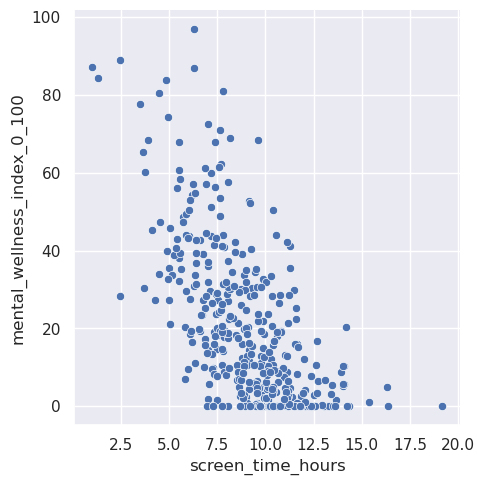

In [12]:
sns.relplot(x='screen_time_hours',y='mental_wellness_index_0_100',data=screen)

<Axes: xlabel='screen_time_hours', ylabel='mental_wellness_index_0_100'>

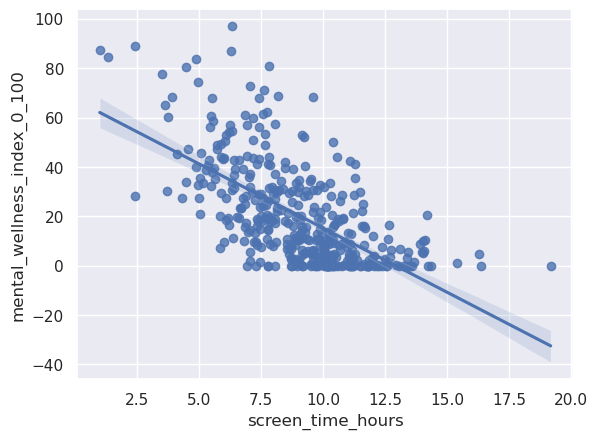

In [13]:
sns.regplot(x='screen_time_hours',y='mental_wellness_index_0_100',data=screen)

In [16]:
stats.pearsonr(screen['screen_time_hours'],screen['mental_wellness_index_0_100'])

PearsonRResult(statistic=np.float64(-0.6359429863421295), pvalue=np.float64(1.021641961200768e-46))

In [14]:
results = smf.ols('mental_wellness_index_0_100 ~ screen_time_hours',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     mental_wellness_index_0_100   R-squared:                       0.404
Model:                                     OLS   Adj. R-squared:                  0.403
Method:                          Least Squares   F-statistic:                     270.3
Date:                         Sun, 22 Feb 2026   Prob (F-statistic):           1.02e-46
Time:                                 20:38:34   Log-Likelihood:                -1669.2
No. Observations:                          400   AIC:                             3342.
Df Residuals:                              398   BIC:                             3350.
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            67.2743      2.962     22.710      0.000      61.451      73.098
screen_time_hours    -5.2020      0.316    -16.440      0.000      -5.824      -4.580
==============================================================================
Omnibus:                       51.291   Durbin-Watson:                   2.061
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               69.274
Skew:                           0.906   Prob(JB):                     9.06e-16
Kurtosis:                       3.934   Cond. No.                         35.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [18]:
results = smf.ols('mental_wellness_index_0_100 ~ + screen_time_hours + sleep_hours + sleep_quality_1_5 + exercise_minutes_per_week',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     mental_wellness_index_0_100   R-squared:                       0.771
Model:                                     OLS   Adj. R-squared:                  0.769
Method:                          Least Squares   F-statistic:                     332.4
Date:                         Sun, 22 Feb 2026   Prob (F-statistic):          5.75e-125
Time:                                 20:41:42   Log-Likelihood:                -1478.0
No. Observations:                          400   AIC:                             2966.
Df Residuals:                              395   BIC:                             2986.
Df Model:                                    4                                         
Covariance Type:                     nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    14.2083      5.456      2.604      0.010       3.483      24.934
screen_time_hours            -3.5889      0.211    -16.979      0.000      -4.004      -3.173
sleep_hours                   1.4770      0.754      1.960      0.051      -0.005       2.959
sleep_quality_1_5            18.1727      0.959     18.953      0.000      16.288      20.058
exercise_minutes_per_week     0.0251      0.007      3.486      0.001       0.011       0.039
==============================================================================
Omnibus:                       15.840   Durbin-Watson:                   2.211
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.515
Skew:                           0.397   Prob(JB):                     9.54e-05
Kurtosis:                       3.694   Cond. No.                     1.47e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.47e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Let's see if I can drop any variable to make this less collinnear.

In [21]:
results = smf.ols('mental_wellness_index_0_100 ~ screen_time_hours + sleep_hours',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     mental_wellness_index_0_100   R-squared:                       0.558
Model:                                     OLS   Adj. R-squared:                  0.556
Method:                          Least Squares   F-statistic:                     250.9
Date:                         Sun, 22 Feb 2026   Prob (F-statistic):           3.60e-71
Time:                                 20:44:54   Log-Likelihood:                -1609.4
No. Observations:                          400   AIC:                             3225.
Df Residuals:                              397   BIC:                             3237.
Df Model:                                    2                                         
Covariance Type:                     nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           -12.5968      7.256     -1.736      0.083     -26.861       1.668
screen_time_hours    -4.0752      0.289    -14.092      0.000      -4.644      -3.507
sleep_hours           9.9387      0.845     11.761      0.000       8.277      11.600
==============================================================================
Omnibus:                       21.282   Durbin-Watson:                   2.026
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               23.155
Skew:                           0.569   Prob(JB):                     9.37e-06
Kurtosis:                       3.305   Cond. No.                         125.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [35]:
results = smf.ols('mental_wellness_index_0_100 ~ screen_time_hours + sleep_hours + sleep_quality_1_5',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     mental_wellness_index_0_100   R-squared:                       0.764
Model:                                     OLS   Adj. R-squared:                  0.762
Method:                          Least Squares   F-statistic:                     427.2
Date:                         Sun, 22 Feb 2026   Prob (F-statistic):          1.01e-123
Time:                                 21:01:37   Log-Likelihood:                -1484.1
No. Observations:                          400   AIC:                             2976.
Df Residuals:                              396   BIC:                             2992.
Df Model:                                    3                                         
Covariance Type:                     nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            15.4048      5.521      2.790      0.006       4.551      26.259
screen_time_hours    -3.6781      0.213    -17.288      0.000      -4.096      -3.260
sleep_hours           1.8395      0.757      2.431      0.016       0.352       3.327
sleep_quality_1_5    18.0434      0.972     18.573      0.000      16.133      19.953
==============================================================================
Omnibus:                       13.547   Durbin-Watson:                   2.187
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               14.162
Skew:                           0.413   Prob(JB):                     0.000841
Kurtosis:                       3.411   Cond. No.                         131.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

That seems to have done the trick.

In [22]:
results = smf.ols('mental_wellness_index_0_100 ~ leisure_screen_hours + sleep_hours',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     mental_wellness_index_0_100   R-squared:                       0.444
Model:                                     OLS   Adj. R-squared:                  0.441
Method:                          Least Squares   F-statistic:                     158.6
Date:                         Sun, 22 Feb 2026   Prob (F-statistic):           2.43e-51
Time:                                 20:45:10   Log-Likelihood:                -1655.4
No. Observations:                          400   AIC:                             3317.
Df Residuals:                              397   BIC:                             3329.
Df Model:                                    2                                         
Covariance Type:                     nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept              -41.3453      7.527     -5.493      0.000     -56.144     -26.547
leisure_screen_hours    -3.1005      0.355     -8.730      0.000      -3.799      -2.402
sleep_hours             11.8185      0.925     12.773      0.000       9.999      13.638
==============================================================================
Omnibus:                       21.489   Durbin-Watson:                   2.156
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               23.411
Skew:                           0.572   Prob(JB):                     8.25e-06
Kurtosis:                       3.313   Cond. No.                         99.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

I want to look at stress vs. sleep.

In [30]:
results = smf.ols('stress_level_0_10 ~ sleep_hours + sleep_quality_1_5',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      stress_level_0_10   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.340
Method:                 Least Squares   F-statistic:                     103.6
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           6.45e-37
Time:                        20:56:06   Log-Likelihood:                -778.90
No. Observations:                 400   AIC:                             1564.
Df Residuals:                     397   BIC:                             1576.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            13.8627      0.773     17.928      0.000      12.343      15.383
sleep_hours          -0.5439      0.127     -4.292      0.000      -0.793      -0.295
sleep_quality_1_5    -1.3580      0.166     -8.201      0.000      -1.684      -1.032
==============================================================================
Omnibus:                       40.256   Durbin-Watson:                   2.234
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               51.679
Skew:                          -0.762   Prob(JB):                     6.00e-12
Kurtosis:                       3.883   Cond. No.                         67.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [34]:
results = smf.ols('stress_level_0_10 ~ screen_time_hours + sleep_hours + sleep_quality_1_5',data=screen).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      stress_level_0_10   R-squared:                       0.634
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                     228.9
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           4.11e-86
Time:                        21:00:30   Log-Likelihood:                -661.71
No. Observations:                 400   AIC:                             1331.
Df Residuals:                     396   BIC:                             1347.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             6.6363      0.706      9.393      0.000       5.247       8.025
screen_time_hours     0.4836      0.027     17.763      0.000       0.430       0.537
sleep_hours          -0.1800      0.097     -1.859      0.064      -0.370       0.010
sleep_quality_1_5    -1.1361      0.124     -9.139      0.000      -1.381      -0.892
==============================================================================
Omnibus:                       13.702   Durbin-Watson:                   2.182
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               14.169
Skew:                          -0.431   Prob(JB):                     0.000838
Kurtosis:                       3.329   Cond. No.                         131.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Mental health seems to have correlations with sleep. Again, this will likely need the input of a domain expert.

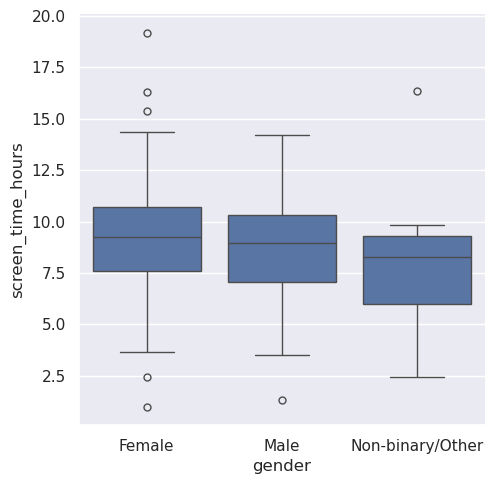

In [5]:
sns.catplot(x='gender',y='screen_time_hours',kind='box',data=screen)

In [6]:
from statsmodels.stats.api import anova_lm
gender_screen_lm = smf.ols("screen_time_hours ~ C(gender)",data=screen).fit()
anova_lm(gender_screen_lm)



,df,sum_sq,mean_sq,F,PR(>F)
C(gender),2.0,11.575441,5.787721,0.932379,0.394476
Residual,397.0,2464.367955,6.207476,NaN,NaN


Gender doesn't seem to be a significant predictor of screen time.

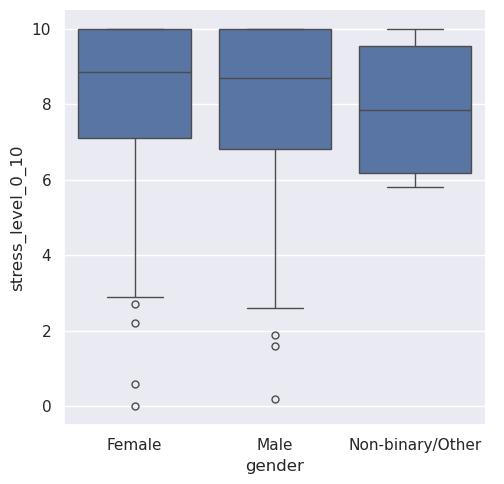

In [7]:
sns.catplot(x='gender',y='stress_level_0_10',kind='box',data=screen)

In [10]:
female_stress = screen.loc[screen["gender"] == "Female", "stress_level_0_10"]
male_stress = screen.loc[screen["gender"] == "Male", "stress_level_0_10"]
nonbinary_stress = screen.loc[screen["gender"] == "Non-binary/Other", "stress_level_0_10"]

stats.kruskal(female_stress,male_stress,nonbinary_stress)

KruskalResult(statistic=np.float64(0.7184105159558031), pvalue=np.float64(0.6982310191549386))

In [14]:
pd.crosstab(screen["gender"],screen["work_mode"])

work_mode,Hybrid,In-person,Remote
gender,,,
Female,75,61,86
Male,67,41,62
Non-binary/Other,4,2,2


In [6]:
import pingouin as pg

pg.chi2_independence(screen,'work_mode','gender')

/home/ddelony/.pixi/envs/stats/lib/python3.14/site-packages/pingouin/contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
/home/ddelony/.pixi/envs/stats/lib/python3.14/site-packages/pingouin/contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


(gender     Female   Male  Non-binary/Other
 work_mode                                 
 Hybrid      81.03  62.05              2.92
 In-person   57.72  44.20              2.08
 Remote      83.25  63.75              3.00,
 gender     Female  Male  Non-binary/Other
 work_mode                                
 Hybrid         75    67                 4
 In-person      61    41                 2
 Remote         86    62                 2,
                  test    lambda      chi2  dof      pval    cramer     power
 0             pearson  1.000000  2.136423  4.0  0.710684  0.051677  0.109695
 1        cressie-read  0.666667  2.136703  4.0  0.710633  0.051681  0.109704
 2      log-likelihood  0.000000  2.142798  4.0  0.709514  0.051754  0.109893
 3       freeman-tukey -0.500000  2.152350  4.0  0.707762  0.051869  0.110190
 4  mod-log-likelihood -1.000000  2.166361  4.0  0.705192  0.052038  0.110625
 5              neyman -2.000000  2.208775  4.0  0.697423  0.052545  0.111947)

In [10]:
contingency = pd.crosstab(screen['work_mode'],screen['gender'])
contingency

gender,Female,Male,Non-binary/Other
work_mode,,,
Hybrid,75,67,4
In-person,61,41,2
Remote,86,62,2


In [9]:
stats.chi2_contingency(contingency)

Chi2ContingencyResult(statistic=np.float64(2.136423003304552), pvalue=np.float64(0.7106840822322684), dof=4, expected_freq=array([[81.03, 62.05,  2.92],
       [57.72, 44.2 ,  2.08],
       [83.25, 63.75,  3.  ]]))

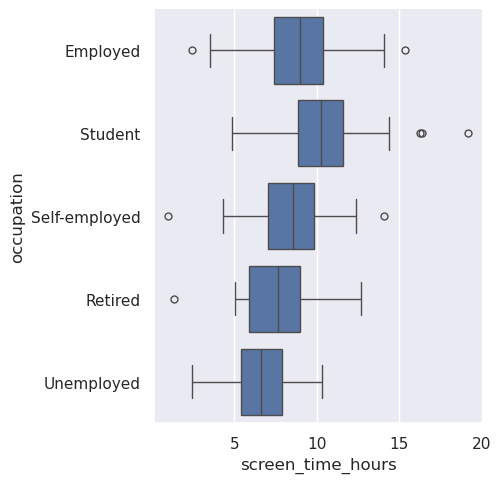

In [5]:
sns.catplot(y='occupation',x='screen_time_hours',kind='box',data=screen)

Screen time across occupation may be significant. Students seem to have the largest screen times.

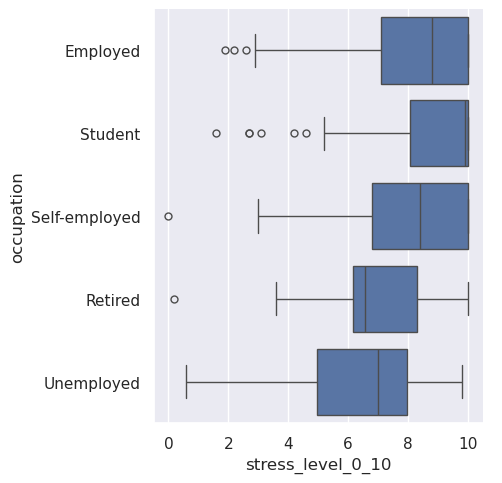

In [6]:
sns.catplot(y='occupation',x='stress_level_0_10',kind='box',data=screen)

In [7]:
student_stress = screen.loc[screen["occupation"] == "Student", "stress_level_0_10"]

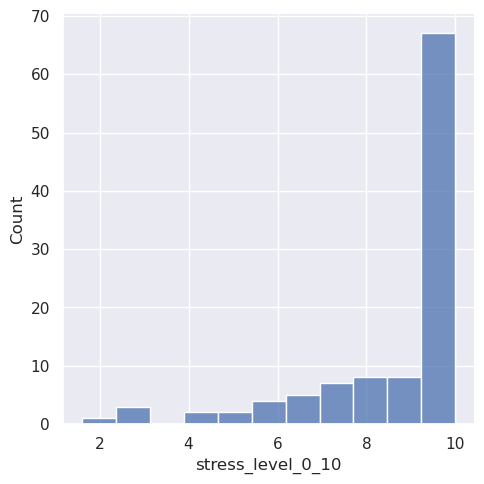

In [8]:
sns.displot(x=student_stress)

In [9]:
student = screen.loc[screen["occupation"] == "Student"]

In [10]:
student.head()

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
4,U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0,NaN
8,U0009,26,Male,Student,In-person,6.28,0.67,5.61,8.48,4,1.6,91.7,149,10.1,86.8,NaN
10,U0011,26,Male,Student,Remote,9.87,3.02,6.85,6.40,1,8.8,55.9,87,6.2,21.8,NaN
12,U0013,31,Female,Student,Remote,12.55,6.80,5.75,6.96,1,10.0,33.0,139,11.3,0.0,NaN
18,U0019,22,Male,Student,Hybrid,8.18,0.70,7.48,9.20,3,4.2,85.1,52,11.2,68.9,NaN


In [11]:
student.describe()

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
count,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,0.0
mean,30.252336,10.333458,3.057664,7.275794,6.958318,1.364486,8.733645,50.039252,108.542056,7.158879,15.539252,NaN
std,7.523665,2.406852,2.389228,2.119912,0.921484,0.731921,1.920738,15.747990,72.457441,4.806598,21.458603,NaN
min,16.000000,4.870000,0.320000,2.590000,4.640000,1.000000,1.600000,23.200000,0.000000,0.000000,0.000000,NaN
25%,24.500000,8.880000,0.890000,5.950000,6.390000,1.000000,8.050000,38.650000,53.000000,3.050000,0.000000,NaN
50%,30.000000,10.260000,2.500000,6.810000,6.840000,1.000000,9.900000,46.500000,100.000000,6.600000,6.600000,NaN
75%,34.000000,11.565000,4.970000,8.795000,7.650000,1.000000,10.000000,58.350000,160.500000,10.250000,21.100000,NaN
max,60.000000,19.170000,12.040000,13.350000,9.740000,4.000000,10.000000,100.000000,291.000000,18.800000,97.000000,NaN


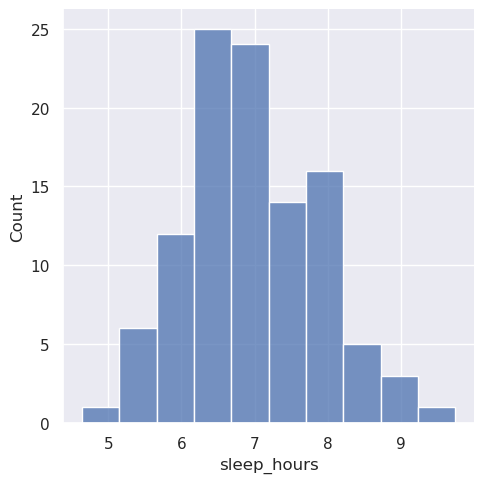

In [12]:
sns.displot(x='sleep_hours',data=student)

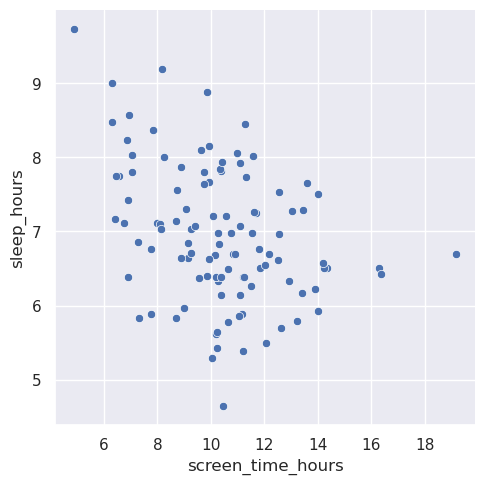

In [13]:
sns.relplot(x='screen_time_hours',y='sleep_hours',data=student)

<Axes: xlabel='screen_time_hours', ylabel='sleep_hours'>

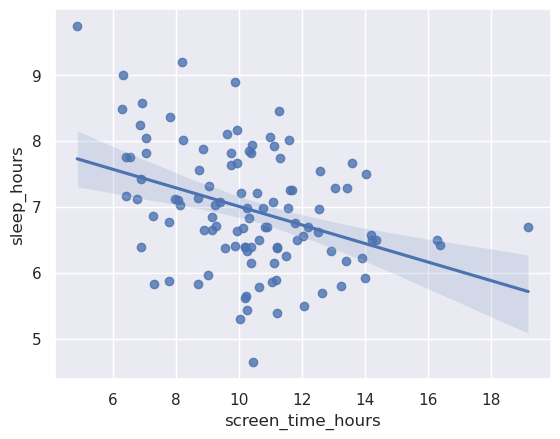

In [14]:
sns.regplot(x='screen_time_hours',y='sleep_hours',data=student)

<Axes: xlabel='screen_time_hours', ylabel='sleep_hours'>

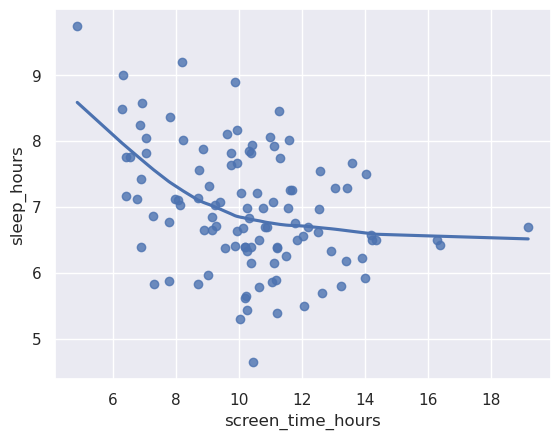

In [15]:
sns.regplot(x='screen_time_hours',y='sleep_hours',lowess=True,data=student)

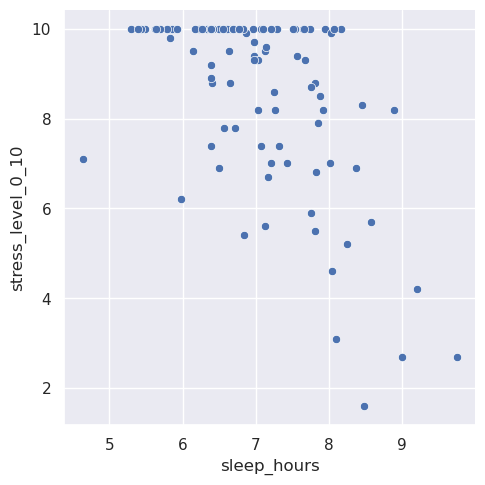

In [16]:
sns.relplot(x='sleep_hours',y='stress_level_0_10',data=student)

<Axes: xlabel='sleep_hours', ylabel='stress_level_0_10'>

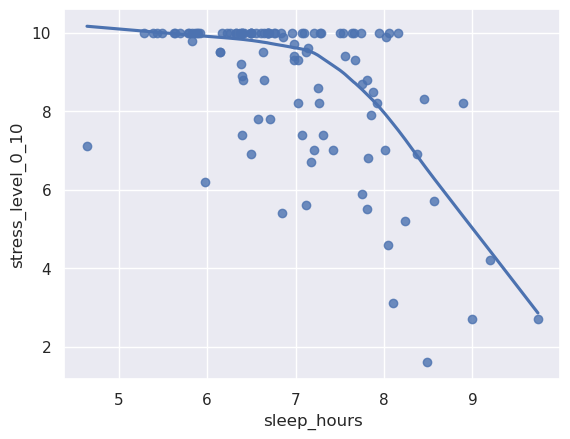

In [17]:
sns.regplot(x='sleep_hours',y='stress_level_0_10',lowess=True,data=student)

This model seems to suggest that stress drops off sharply around seven hours of sleep a night.

<Axes: xlabel='sleep_hours', ylabel='stress_level_0_10'>

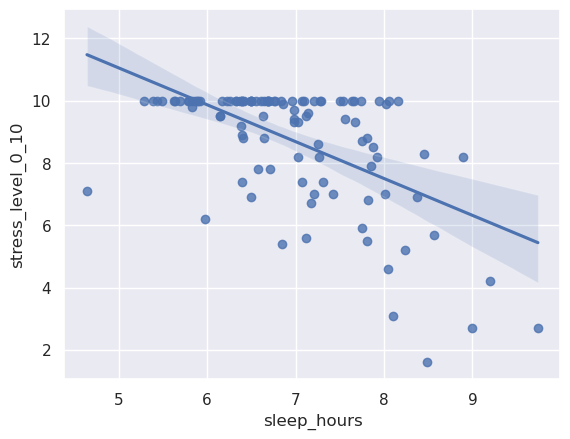

In [18]:
sns.regplot(x='sleep_hours',y='stress_level_0_10',data=student)

In [23]:
student['log10stress'] = np.log10(student['stress_level_0_10'])

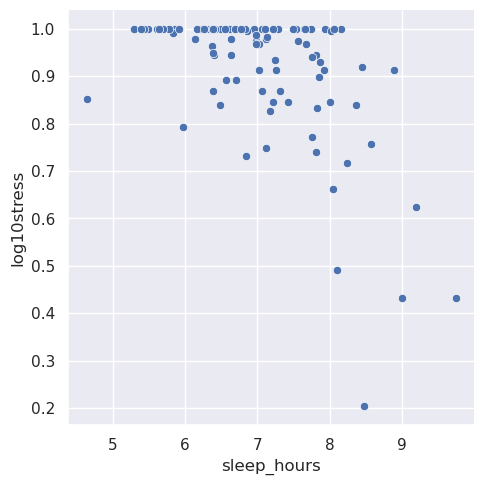

In [24]:
sns.relplot(x='sleep_hours',y='log10stress',data=student)

In [25]:
student['log10sleep'] = np.log10(student['sleep_hours'])

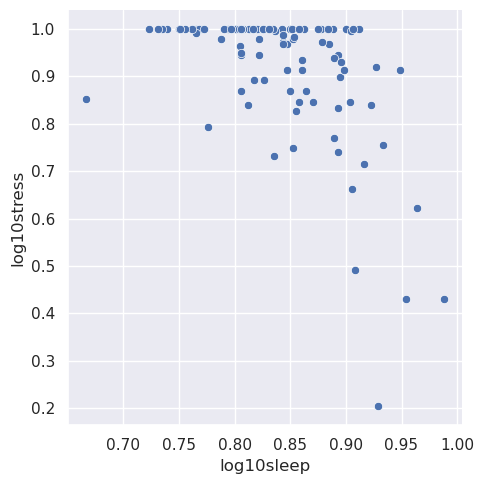

In [26]:
sns.relplot(x='log10sleep',y='log10stress',data=student)

In [5]:
from scipy.stats import t
df = len(screen) - 1
mean = screen['sleep_hours'].mean()
std = stats.sem(screen['sleep_hours'])

t.interval(.95,df=df,loc=mean,scale=std)

(np.float64(6.929385133959015), np.float64(7.096964866040985))

In [6]:
from scipy.stats import t
df = len(screen) - 1
mean = screen['screen_time_hours'].mean()
std = stats.sem(screen['screen_time_hours'])

t.interval(.95,df=df,loc=mean,scale=std)

(np.float64(8.780038015424816), np.float64(9.269761984575185))

In [8]:
from scipy.stats import t
df = len(screen) - 1
mean = screen['productivity_0_100'].mean()
std = stats.sem(screen['productivity_0_100'])

t.interval(.95,df=df,loc=mean,scale=std)

(np.float64(52.83008332345583), np.float64(55.78291667654418))